开始加载数据...
特征维度: (132, 3), 目标维度: (132, 5)
训练集: 84, 验证集: 21, 测试集: 27

开始训练 LightGBM 模型（为每个目标独立建模）...
  训练目标: CL
    最佳迭代轮数: 163
  训练目标: CD
    最佳迭代轮数: 119
  训练目标: CN
    最佳迭代轮数: 124
  训练目标: CA
    最佳迭代轮数: 187
  训练目标: CM
    最佳迭代轮数: 81

===== 测试集评估结果（原始尺度） =====
总体指标: MSE=0.011749, RMSE=0.108393, MAE=0.061665, R2=0.838156, Combined=0.032099

各分量详细指标:
CL: RMSE=0.186880, MAE=0.143679, R2=0.769787, MRE=36.7454%
CD: RMSE=0.047004, MAE=0.032281, R2=0.987215, MRE=10.1877%
CN: RMSE=0.145806, MAE=0.113788, R2=0.917857, MRE=29.2714%
CA: RMSE=0.016444, MAE=0.011951, R2=0.536393, MRE=106.3076%
CM: RMSE=0.009069, MAE=0.006625, R2=0.979529, MRE=10.8530%

===== 训练集评估结果 =====
总体RMSE=0.098494, R2=0.897721

===== 验证集评估结果 =====
总体RMSE=0.090877, R2=0.907044


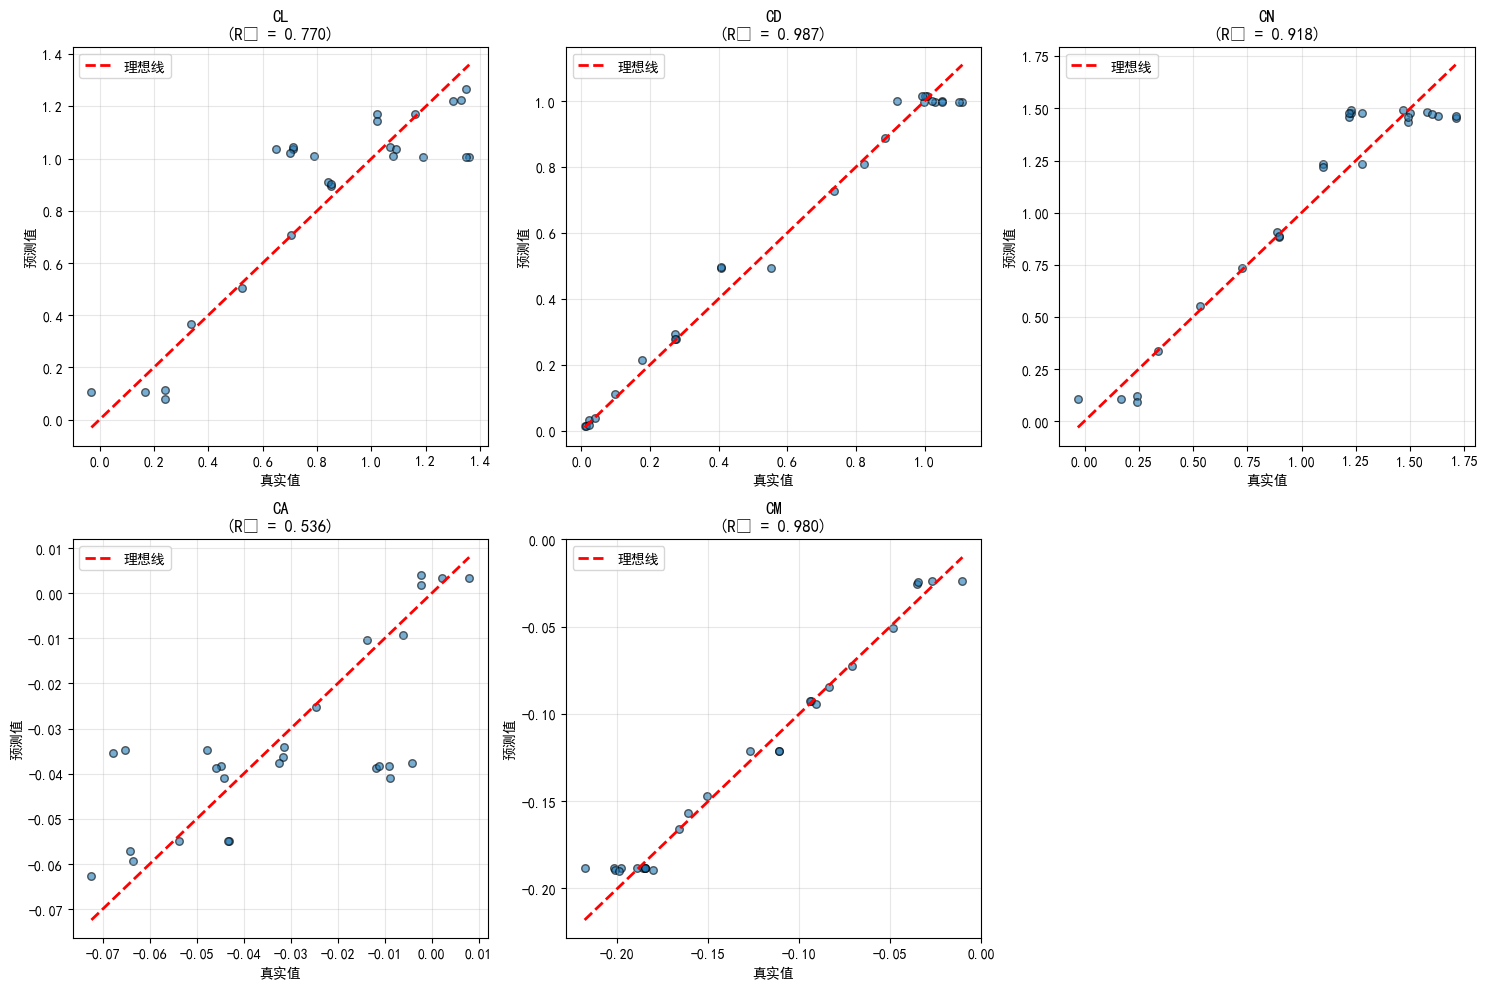

对比图已保存至 lgb_component_comparison.png

LightGBM 对比实验完成！


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# ==================== 数据加载与预处理 ====================
print("开始加载数据...")
df = pd.read_excel('data_all.xlsx')
feature_columns = ['MA', 'BETA', 'AA']
target_columns = ['CL', 'CD', 'CN', 'CA', 'CM']
X = df[feature_columns].values
y = df[target_columns].values
print(f"特征维度: {X.shape}, 目标维度: {y.shape}")

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

print(f"训练集: {X_train_scaled.shape[0]}, 验证集: {X_val_scaled.shape[0]}, 测试集: {X_test_scaled.shape[0]}")

# ==================== LightGBM 多输出模型（每个目标独立训练） ====================
print("\n开始训练 LightGBM 模型（为每个目标独立建模）...")

# 定义通用参数
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbosity': -1,
    'n_estimators': 300
}

# 为每个目标训练一个模型
lgb_models = []
for i, target_name in enumerate(target_columns):
    print(f"  训练目标: {target_name}")
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_scaled, y_train_scaled[:, i],
        eval_set=[(X_val_scaled, y_val_scaled[:, i])],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    lgb_models.append(model)
    print(f"    最佳迭代轮数: {model.best_iteration_}")

# 预测函数：组合各模型输出
def predict_lgb(models, X):
    preds = np.zeros((X.shape[0], len(models)))
    for i, model in enumerate(models):
        preds[:, i] = model.predict(X)
    return preds

# ==================== 评估函数 ====================
def evaluate_model(predict_func, X, y_true_scaled, scaler_y):
    y_pred_scaled = predict_func(X)
    y_true_orig = scaler_y.inverse_transform(y_true_scaled)
    y_pred_orig = scaler_y.inverse_transform(y_pred_scaled)

    total_mse = mean_squared_error(y_true_orig, y_pred_orig)
    total_rmse = np.sqrt(total_mse)
    total_mae = mean_absolute_error(y_true_orig, y_pred_orig)
    total_r2 = r2_score(y_true_orig, y_pred_orig)
    mse_loss = np.mean((y_true_orig - y_pred_orig) ** 2)
    mae_loss = np.mean(np.abs(y_true_orig - y_pred_orig))
    total_combined = mse_loss + 0.33 * mae_loss

    n_outputs = y_true_orig.shape[1]
    component_metrics = {}
    for i in range(n_outputs):
        y_true_i = y_true_orig[:, i]
        y_pred_i = y_pred_orig[:, i]
        rmse_i = np.sqrt(mean_squared_error(y_true_i, y_pred_i))
        mae_i = mean_absolute_error(y_true_i, y_pred_i)
        r2_i = r2_score(y_true_i, y_pred_i)
        epsilon = 1e-8
        mre_i = np.mean(np.abs((y_true_i - y_pred_i) / (np.abs(y_true_i) + epsilon)))
        component_metrics[i] = {'RMSE': rmse_i, 'MAE': mae_i, 'R2': r2_i, 'MRE': mre_i}

    overall_metrics = {
        'MSE': total_mse,
        'RMSE': total_rmse,
        'MAE': total_mae,
        'R2': total_r2,
        'Combined_Loss': total_combined
    }
    return overall_metrics, component_metrics, (y_true_orig, y_pred_orig)

# ==================== 评估 ====================
print("\n===== 测试集评估结果（原始尺度） =====")
predict_func = lambda X: predict_lgb(lgb_models, X)
test_overall, test_component, (test_true, test_pred) = evaluate_model(predict_func, X_test_scaled, y_test_scaled, scaler_y)

print(f"总体指标: MSE={test_overall['MSE']:.6f}, RMSE={test_overall['RMSE']:.6f}, MAE={test_overall['MAE']:.6f}, R2={test_overall['R2']:.6f}, Combined={test_overall['Combined_Loss']:.6f}")

print("\n各分量详细指标:")
for i, name in enumerate(target_columns):
    m = test_component[i]
    print(f"{name}: RMSE={m['RMSE']:.6f}, MAE={m['MAE']:.6f}, R2={m['R2']:.6f}, MRE={m['MRE']:.4%}")

print("\n===== 训练集评估结果 =====")
train_overall, _, _ = evaluate_model(predict_func, X_train_scaled, y_train_scaled, scaler_y)
print(f"总体RMSE={train_overall['RMSE']:.6f}, R2={train_overall['R2']:.6f}")

print("\n===== 验证集评估结果 =====")
val_overall, _, _ = evaluate_model(predict_func, X_val_scaled, y_val_scaled, scaler_y)
print(f"总体RMSE={val_overall['RMSE']:.6f}, R2={val_overall['R2']:.6f}")

# ==================== 可视化 ====================
def plot_true_vs_pred(true, pred, target_names, component_metrics, save_path='lgb_component_comparison.png'):
    n = len(target_names)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for i, name in enumerate(target_names):
        ax = axes[i]
        ax.scatter(true[:, i], pred[:, i], alpha=0.6, edgecolors='k', s=30)
        min_val = min(true[:, i].min(), pred[:, i].min())
        max_val = max(true[:, i].max(), pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='理想线')
        ax.set_xlabel('真实值')
        ax.set_ylabel('预测值')
        ax.set_title(f'{name}\n(R² = {component_metrics[i]["R2"]:.3f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    if n < len(axes):
        axes[-1].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"对比图已保存至 {save_path}")

plot_true_vs_pred(test_true, test_pred, target_columns, test_component, save_path='lgb_component_comparison.png')

print("\nLightGBM 对比实验完成！")